# Homework 5 Problem 1: ViT vs. ResNet-18

**Course:** ECGR 4106  
**Student:** Gilberto Feliu  
**Student ID:** 801257813  
**Dataset:** CIFAR-100

This notebook is the executed Python notebook for Problem 1. It shows the implementation in small readable blocks, then loads the completed CSV artifacts to present the final tables, per-epoch histories, training curves, and tradeoff plots. The goal is to make the grading path clear: the TA can inspect the model code, see how the runs were recorded, and verify that the final numbers are connected to actual training outputs.


## Experiment Setup

Problem 1 compares four from-scratch Vision Transformer configurations against a CIFAR-adapted ResNet-18 baseline. The ViT models vary patch size, embedding dimension, depth, attention heads, and MLP width. All runs use CIFAR-100, batch size 64, Adam with learning rate 0.001, and 10 epochs.

The ResNet-18 baseline is not treated as a black-box result. Its CIFAR-specific stem is included in the source below, and the same reporting pipeline records its loss, accuracy, parameter count, estimated FLOPs, and timing.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Code, Image, Markdown, display

ROOT = Path.cwd()
__file__ = str(ROOT / 'src' / 'hw5_vit_resnet.py')
RESULTS = ROOT / 'Results_Problem_1'
history_path = RESULTS / 'problem1_history.csv'
summary_path = RESULTS / 'problem1_summary.csv'
plot_path = RESULTS / 'problem1_loss_curves.png'
detail_path = RESULTS / 'problem1_epoch_detail.png'
metric_grid_path = RESULTS / 'problem1_metric_grid.png'
tradeoff_path = RESULTS / 'problem1_tradeoffs.png'
print('Summary:', summary_path)
print('History:', history_path)
print('Training plot:', plot_path)
print('Detail plot:', detail_path)
print('Metric grid:', metric_grid_path)
print('Tradeoff plot:', tradeoff_path)

Summary: /home/gilberto/Homework_5/Results_Problem_1/problem1_summary.csv
History: /home/gilberto/Homework_5/Results_Problem_1/problem1_history.csv
Training plot: /home/gilberto/Homework_5/Results_Problem_1/problem1_loss_curves.png
Detail plot: /home/gilberto/Homework_5/Results_Problem_1/problem1_epoch_detail.png
Metric grid: /home/gilberto/Homework_5/Results_Problem_1/problem1_metric_grid.png
Tradeoff plot: /home/gilberto/Homework_5/Results_Problem_1/problem1_tradeoffs.png


## Source Walkthrough

I split the implementation into the same order I used to build and check the experiment. The cells below are normal Python cells, not display wrappers. They define the pieces of the training pipeline without launching the full training run again. The final script launcher is disabled only in this notebook copy so the notebook can be opened and executed safely while the real command-line script in `src/` remains runnable.


### Step 1: Imports, Constants, and Paths

I start with the imports and run-level constants. This is where the device fallback happens, so the same script can run on CUDA when available or CPU when it is not.


In [2]:
from __future__ import annotations

import argparse
import csv
import math
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms


torch.set_num_threads(2)
SEED = 4106
ROOT = Path(__file__).resolve().parents[1]
DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "Results_Problem_1"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 32
NUM_CLASSES = 100



print('Loaded imports, paths, constants, and device selection.')


Loaded imports, paths, constants, and device selection.


### Step 2: Experiment Records

These dataclasses are the bookkeeping layer. They keep every configuration and final result row consistent, which makes the summary tables easier to trust.


In [3]:
@dataclass
class ExperimentConfig:
    model_name: str
    patch_size: int | None
    embed_dim: int | None
    depth: int | None
    heads: int | None
    mlp_dim: int | None
    batch_size: int
    epochs: int
    learning_rate: float


@dataclass
class ExperimentResult:
    model_name: str
    patch_size: int | None
    embed_dim: int | None
    depth: int | None
    heads: int | None
    mlp_dim: int | None
    parameter_count: int | None
    flops_forward: float | None
    train_time_per_epoch_sec: float | None
    final_train_loss: float | None
    final_val_loss: float | None
    test_accuracy_pct: float | None
    notes: str = ""



print('Defined structured records for configurations and final metrics.')


Defined structured records for configurations and final metrics.


### Step 3: Reproducibility and Small Utilities

This section sets the random seed, creates result folders, counts trainable parameters, and computes top-1 accuracy. These are small functions, but they keep the metrics consistent across all five models.


In [4]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def ensure_dirs() -> None:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def count_parameters(model: nn.Module) -> int:
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


def accuracy_from_logits(logits: torch.Tensor, targets: torch.Tensor) -> float:
    predictions = logits.argmax(dim=1)
    return 100.0 * predictions.eq(targets).sum().item() / max(1, targets.numel())



print('Loaded reproducibility helpers and metric utilities.')


Loaded reproducibility helpers and metric utilities.


### Step 4: Vision Transformer Model

This is the from-scratch ViT. It turns CIFAR images into patch tokens, adds a class token and positional embeddings, sends the sequence through transformer encoder blocks, and classifies from the final class-token representation.


In [5]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size: int, patch_size: int, in_channels: int, embed_dim: int) -> None:
        super().__init__()
        if image_size % patch_size != 0:
            raise ValueError("image_size must be divisible by patch_size")
        self.image_size = image_size
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.num_patches = self.grid_size * self.grid_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.proj(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class ViTClassifier(nn.Module):
    def __init__(
        self,
        image_size: int = IMAGE_SIZE,
        patch_size: int = 4,
        in_channels: int = 3,
        num_classes: int = NUM_CLASSES,
        embed_dim: int = 256,
        depth: int = 4,
        heads: int = 4,
        mlp_dim: int = 1024,
        dropout: float = 0.1,
    ) -> None:
        super().__init__()
        self.patch_embed = PatchEmbedding(image_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.num_patches
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embedding = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=mlp_dim,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
        self._reset_parameters()

    def _reset_parameters(self) -> None:
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embedding, std=0.02)
        nn.init.trunc_normal_(self.head.weight, std=0.02)
        nn.init.zeros_(self.head.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.patch_embed(x)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1)
        x = x + self.pos_embedding[:, : x.size(1)]
        x = self.encoder(x)
        x = self.norm(x[:, 0])
        return self.head(x)



print('Defined the from-scratch ViT architecture.')


Defined the from-scratch ViT architecture.


### Step 5: ResNet-18 Baseline

This is the CNN comparison model. I adapt ResNet-18 for 32 by 32 CIFAR images by using a smaller first convolution and removing the initial max pool.


In [6]:
def build_resnet18(num_classes: int = NUM_CLASSES) -> nn.Module:
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model



print('Defined the CIFAR-adapted ResNet-18 baseline.')


Defined the CIFAR-adapted ResNet-18 baseline.


### Step 6: CIFAR-100 Data and Evaluation

This is the data pipeline and test-set evaluation pass. Training uses light image augmentation, while evaluation uses deterministic preprocessing so the reported accuracy is stable.


In [7]:
def get_cifar100_loaders(batch_size: int, num_workers: int = 0) -> tuple[DataLoader, DataLoader]:
    train_transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    ])
    test_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    ])
    train_dataset = datasets.CIFAR100(root=DATA_DIR, train=True, download=True, transform=train_transform)
    test_dataset = datasets.CIFAR100(root=DATA_DIR, train=False, download=True, transform=test_transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())
    return train_loader, test_loader


def evaluate_model(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)
            logits = model(inputs)
            loss = criterion(logits, targets)
            total_loss += loss.item() * targets.size(0)
            total_correct += logits.argmax(dim=1).eq(targets).sum().item()
            total_samples += targets.size(0)
    return {
        "loss": total_loss / max(1, total_samples),
        "accuracy_pct": 100.0 * total_correct / max(1, total_samples),
    }



print('Defined CIFAR-100 loaders and the evaluation pass.')


Defined CIFAR-100 loaders and the evaluation pass.


### Step 7: Training Loop

This is where each model actually trains. The loop records loss, accuracy, and wall-clock time every epoch so the final report can show learning curves instead of only final numbers.


In [8]:
def train_model(model: nn.Module, config: ExperimentConfig, train_loader: DataLoader, test_loader: DataLoader) -> tuple[list[dict[str, float]], ExperimentResult]:
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate)
    criterion = nn.CrossEntropyLoss()
    history: list[dict[str, float]] = []
    start_all = time.perf_counter()
    for epoch in range(1, config.epochs + 1):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0
        start_epoch = time.perf_counter()
        for inputs, targets in train_loader:
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(inputs)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * targets.size(0)
            total_correct += logits.argmax(dim=1).eq(targets).sum().item()
            total_samples += targets.size(0)
        test_metrics = evaluate_model(model, test_loader, criterion)
        history.append({
            "model_name": config.model_name,
            "epoch": epoch,
            "train_loss": total_loss / max(1, total_samples),
            "val_loss": test_metrics["loss"],
            "train_accuracy_pct": 100.0 * total_correct / max(1, total_samples),
            "val_accuracy_pct": test_metrics["accuracy_pct"],
            "epoch_seconds": time.perf_counter() - start_epoch,
        })
        latest = history[-1]
        print(
            f"{config.model_name} epoch {epoch}/{config.epochs}: "
            f"train_loss={latest['train_loss']:.4f}, "
            f"val_loss={latest['val_loss']:.4f}, "
            f"val_acc={latest['val_accuracy_pct']:.2f}%, "
            f"seconds={latest['epoch_seconds']:.1f}",
            flush=True,
        )

    average_epoch_seconds = (time.perf_counter() - start_all) / max(1, config.epochs)
    final = history[-1]
    result = ExperimentResult(
        model_name=config.model_name,
        patch_size=config.patch_size,
        embed_dim=config.embed_dim,
        depth=config.depth,
        heads=config.heads,
        mlp_dim=config.mlp_dim,
        parameter_count=count_parameters(model),
        flops_forward=estimate_flops(config),
        train_time_per_epoch_sec=average_epoch_seconds,
        final_train_loss=final["train_loss"],
        final_val_loss=final["val_loss"],
        test_accuracy_pct=final["val_accuracy_pct"],
        notes=f"device={DEVICE.type}",
    )
    return history, result



print('Defined the training loop and per-epoch history collection.')


Defined the training loop and per-epoch history collection.


### Step 8: Complexity and CSV Reporting

This section estimates FLOPs and writes the CSV artifacts. Those files feed the notebook tables, the plots, and the PDF report.


In [9]:
def estimate_flops(config: ExperimentConfig) -> float | None:
    if config.model_name == "resnet18":
        # CIFAR-adapted ResNet-18: 3x3 stride-1 stem and no initial max pool.
        return 555_468_800.0
    if config.patch_size is None or config.embed_dim is None or config.depth is None or config.heads is None or config.mlp_dim is None:
        return None
    tokens = (IMAGE_SIZE // config.patch_size) ** 2 + 1
    d = config.embed_dim
    depth = config.depth
    attn = depth * (4 * tokens * d * d + 2 * tokens * tokens * d)
    mlp = depth * (2 * tokens * d * config.mlp_dim)
    head = d * NUM_CLASSES
    return float(attn + mlp + head)


def append_history_rows(rows: list[dict[str, float]]) -> None:
    history_path = RESULTS_DIR / "problem1_history.csv"
    exists = history_path.exists()
    with history_path.open("a", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0].keys()))
        if not exists or history_path.stat().st_size == 0:
            writer.writeheader()
        for row in rows:
            writer.writerow(row)


def write_summary(rows: list[ExperimentResult]) -> None:
    summary_path = RESULTS_DIR / "problem1_summary.csv"
    with summary_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(asdict(rows[0]).keys()))
        writer.writeheader()
        for row in rows:
            writer.writerow(asdict(row))



print('Defined FLOP estimates and CSV output helpers.')


Defined FLOP estimates and CSV output helpers.


### Step 9: Experiment Configurations

Here are the required ViT settings and runner functions. The four ViT rows match the patch sizes, embedding dimensions, depths, heads, and MLP widths requested in the prompt.


In [10]:
def default_vit_configs() -> list[ExperimentConfig]:
    return [
        ExperimentConfig("vit_patch4_dim256_d4_h4", 4, 256, 4, 4, 1024, 64, 10, 1e-3),
        ExperimentConfig("vit_patch4_dim512_d8_h8", 4, 512, 8, 8, 2048, 64, 10, 1e-3),
        ExperimentConfig("vit_patch8_dim256_d4_h4", 8, 256, 4, 4, 1024, 64, 10, 1e-3),
        ExperimentConfig("vit_patch8_dim512_d8_h8", 8, 512, 8, 8, 2048, 64, 10, 1e-3),
    ]


def build_vit_from_config(config: ExperimentConfig) -> ViTClassifier:
    return ViTClassifier(
        patch_size=config.patch_size or 4,
        embed_dim=config.embed_dim or 256,
        depth=config.depth or 4,
        heads=config.heads or 4,
        mlp_dim=config.mlp_dim or 1024,
    )


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Homework 5 Problem 1: ViT vs ResNet-18")
    parser.add_argument("--run-all-vit", action="store_true")
    parser.add_argument("--run-vit", type=str, default=None, help="Specific ViT config name to run")
    parser.add_argument("--run-resnet", action="store_true")
    parser.add_argument("--epochs", type=int, default=None)
    parser.add_argument("--batch-size", type=int, default=None)
    parser.add_argument("--num-workers", type=int, default=0)
    parser.add_argument("--reset-history", action="store_true")
    return parser.parse_args()


def maybe_reset_history() -> None:
    history_path = RESULTS_DIR / "problem1_history.csv"
    if history_path.exists():
        history_path.unlink()


def select_vit_configs(args: argparse.Namespace) -> list[ExperimentConfig]:
    configs = default_vit_configs()
    if args.run_vit:
        configs = [config for config in configs if config.model_name == args.run_vit]
        if not configs:
            raise ValueError(f"Unknown ViT config: {args.run_vit}")
    if args.epochs is not None or args.batch_size is not None:
        updated: list[ExperimentConfig] = []
        for config in configs:
            updated.append(ExperimentConfig(
                model_name=config.model_name,
                patch_size=config.patch_size,
                embed_dim=config.embed_dim,
                depth=config.depth,
                heads=config.heads,
                mlp_dim=config.mlp_dim,
                batch_size=args.batch_size or config.batch_size,
                epochs=args.epochs or config.epochs,
                learning_rate=config.learning_rate,
            ))
        configs = updated
    return configs


def run_vit_experiments(args: argparse.Namespace) -> list[ExperimentResult]:
    results: list[ExperimentResult] = []
    for config in select_vit_configs(args):
        train_loader, test_loader = get_cifar100_loaders(config.batch_size, args.num_workers)
        history, result = train_model(build_vit_from_config(config), config, train_loader, test_loader)
        append_history_rows(history)
        results.append(result)
    return results


def run_resnet_experiment(args: argparse.Namespace) -> ExperimentResult:
    batch_size = args.batch_size or 64
    epochs = args.epochs or 10
    config = ExperimentConfig("resnet18", None, None, None, None, None, batch_size, epochs, 1e-3)
    train_loader, test_loader = get_cifar100_loaders(config.batch_size, args.num_workers)
    history, result = train_model(build_resnet18(), config, train_loader, test_loader)
    append_history_rows(history)
    return result



print('Defined the required experiment configurations and runners.')


Defined the required experiment configurations and runners.


### Step 10: Summary and Script Entry Point

This final section merges results into the summary table and defines the command-line entry point used to reproduce the runs from the terminal.


In [11]:
def refresh_summary_with_results(results: list[ExperimentResult]) -> None:
    summary_path = RESULTS_DIR / "problem1_summary.csv"
    if summary_path.exists():
        existing = pd.read_csv(summary_path)
        by_name = {result.model_name: asdict(result) for result in results}
        rows = []
        for record in existing.to_dict(orient="records"):
            if record["model_name"] in by_name:
                rows.append(by_name[record["model_name"]])
            else:
                rows.append(record)
        final_rows = [ExperimentResult(**row) for row in rows]
        write_summary(final_rows)
        return
    write_summary(results)


def main() -> None:
    args = parse_args()
    set_seed()
    ensure_dirs()
    if args.reset_history:
        maybe_reset_history()

    collected: list[ExperimentResult] = []
    if args.run_all_vit or args.run_vit:
        collected.extend(run_vit_experiments(args))
    if args.run_resnet:
        collected.append(run_resnet_experiment(args))

    if not collected:
        print("Nothing ran. Use --run-all-vit, --run-vit <name>, or --run-resnet.")
        return

    refresh_summary_with_results(collected)
    print(pd.DataFrame([asdict(result) for result in collected]).to_string(index=False))


if False and __name__ == "__main__":
    main()

print('Defined summary refresh logic and the script entry point.')


Defined summary refresh logic and the script entry point.


## Results Loaded From the Completed Runs

The code above defines the experiment. The cells below load the artifacts that were produced by the completed training runs: summary CSVs, history CSVs, and generated figures. This keeps the notebook fast to open while still showing the actual outputs used in the report.


## Summary Results

The table below is read directly from `Results_Problem_1/problem1_summary.csv`. Every planned row includes completed 10-epoch training metrics, parameter counts, estimated FLOPs, runtime, and final accuracy. This is the main grading table for Problem 1 because it places the four ViT configurations and ResNet-18 on the same scale.


In [12]:
summary_df = pd.read_csv(summary_path, keep_default_na=False)
summary_df

,model_name,patch_size,embed_dim,depth,heads,mlp_dim,parameter_count,flops_forward,train_time_per_epoch_sec,final_train_loss,final_val_loss,test_accuracy_pct,notes
0,vit_patch4_dim256_d4_h4,4,256,4,4,1024,3214692,2.131507e+08,23.014994,3.325062,3.283429,20.01,device=cuda
1,vit_patch4_dim512_d8_h8,4,512,8,8,2048,25330276,1.670441e+09,106.715145,4.303222,4.323157,4.51,device=cuda
2,vit_patch8_dim256_d4_h4,8,256,4,4,1024,3239268,5.409485e+07,12.217159,3.902182,3.885059,9.68,device=cuda
3,vit_patch8_dim512_d8_h8,8,512,8,8,2048,25379428,4.302377e+08,42.299152,4.227836,4.269351,4.95,device=cuda
4,resnet18,,,,,,11220132,5.554688e+08,61.236564,1.048969,1.391882,61.20,device=cuda


## Clean Report Table

This view formats the most important columns for reading inside the notebook. It is the same information used in the report table, just displayed with cleaner column ordering.


In [13]:
report_cols = [
    'model_name', 'parameter_count', 'flops_forward',
    'train_time_per_epoch_sec', 'final_val_loss', 'test_accuracy_pct', 'notes'
]
report_df = summary_df[report_cols].copy()
report_df.columns = ['Model', 'Params', 'FLOPs / Forward', 'Time / Epoch (s)', 'Final Val Loss', 'Test Accuracy (%)', 'Status']
report_df

,Model,Params,FLOPs / Forward,Time / Epoch (s),Final Val Loss,Test Accuracy (%),Status
0,vit_patch4_dim256_d4_h4,3214692,2.131507e+08,23.014994,3.283429,20.01,device=cuda
1,vit_patch4_dim512_d8_h8,25330276,1.670441e+09,106.715145,4.323157,4.51,device=cuda
2,vit_patch8_dim256_d4_h4,3239268,5.409485e+07,12.217159,3.885059,9.68,device=cuda
3,vit_patch8_dim512_d8_h8,25379428,4.302377e+08,42.299152,4.269351,4.95,device=cuda
4,resnet18,11220132,5.554688e+08,61.236564,1.391882,61.20,device=cuda


## Per-Epoch History

A complete Problem 1 run should produce 50 history rows: 5 models times 10 epochs. The history file is important because it proves the final numbers are not isolated screenshots; it contains the learning curves used to verify whether each model was actually improving during training.


In [14]:
history_df = pd.read_csv(history_path)
print(f'History rows: {len(history_df)}')
history_df

History rows: 50


,model_name,epoch,train_loss,val_loss,train_accuracy_pct,val_accuracy_pct,epoch_seconds
0,vit_patch4_dim256_d4_h4,1,4.010155,3.759034,7.828,11.36,23.015639
1,vit_patch4_dim256_d4_h4,2,3.738646,3.665595,11.850,13.50,22.786489
2,vit_patch4_dim256_d4_h4,3,3.640890,3.556376,13.436,14.62,22.918571
3,vit_patch4_dim256_d4_h4,4,3.606052,3.507664,14.038,16.03,23.130308
4,vit_patch4_dim256_d4_h4,5,3.554222,3.522711,14.900,16.13,23.087703
5,vit_patch4_dim256_d4_h4,6,3.535617,3.425678,15.396,17.34,22.934365
6,vit_patch4_dim256_d4_h4,7,3.436794,3.465146,17.226,17.02,22.914715
7,vit_patch4_dim256_d4_h4,8,3.438895,3.348804,17.018,18.73,23.025334
8,vit_patch4_dim256_d4_h4,9,3.347852,3.299602,18.770,19.72,23.194426
9,vit_patch4_dim256_d4_h4,10,3.325062,3.283429,19.102,20.01,23.141071


## Training and Tradeoff Figures

The first figure shows loss and accuracy for every epoch with solid lines and visible markers. The second figure summarizes the final tradeoffs among accuracy, runtime, model size, and estimated compute. Together these figures answer the TA feedback point about showing and discussing whether the models were learning. I also include a per-model detail figure so every real epoch point is visible and labeled, instead of relying only on the combined overview plot. The metric grid gives a denser view by plotting train loss, test loss, train accuracy, and test accuracy separately for each model, with every real epoch value labeled.


### Loss and Accuracy Curves

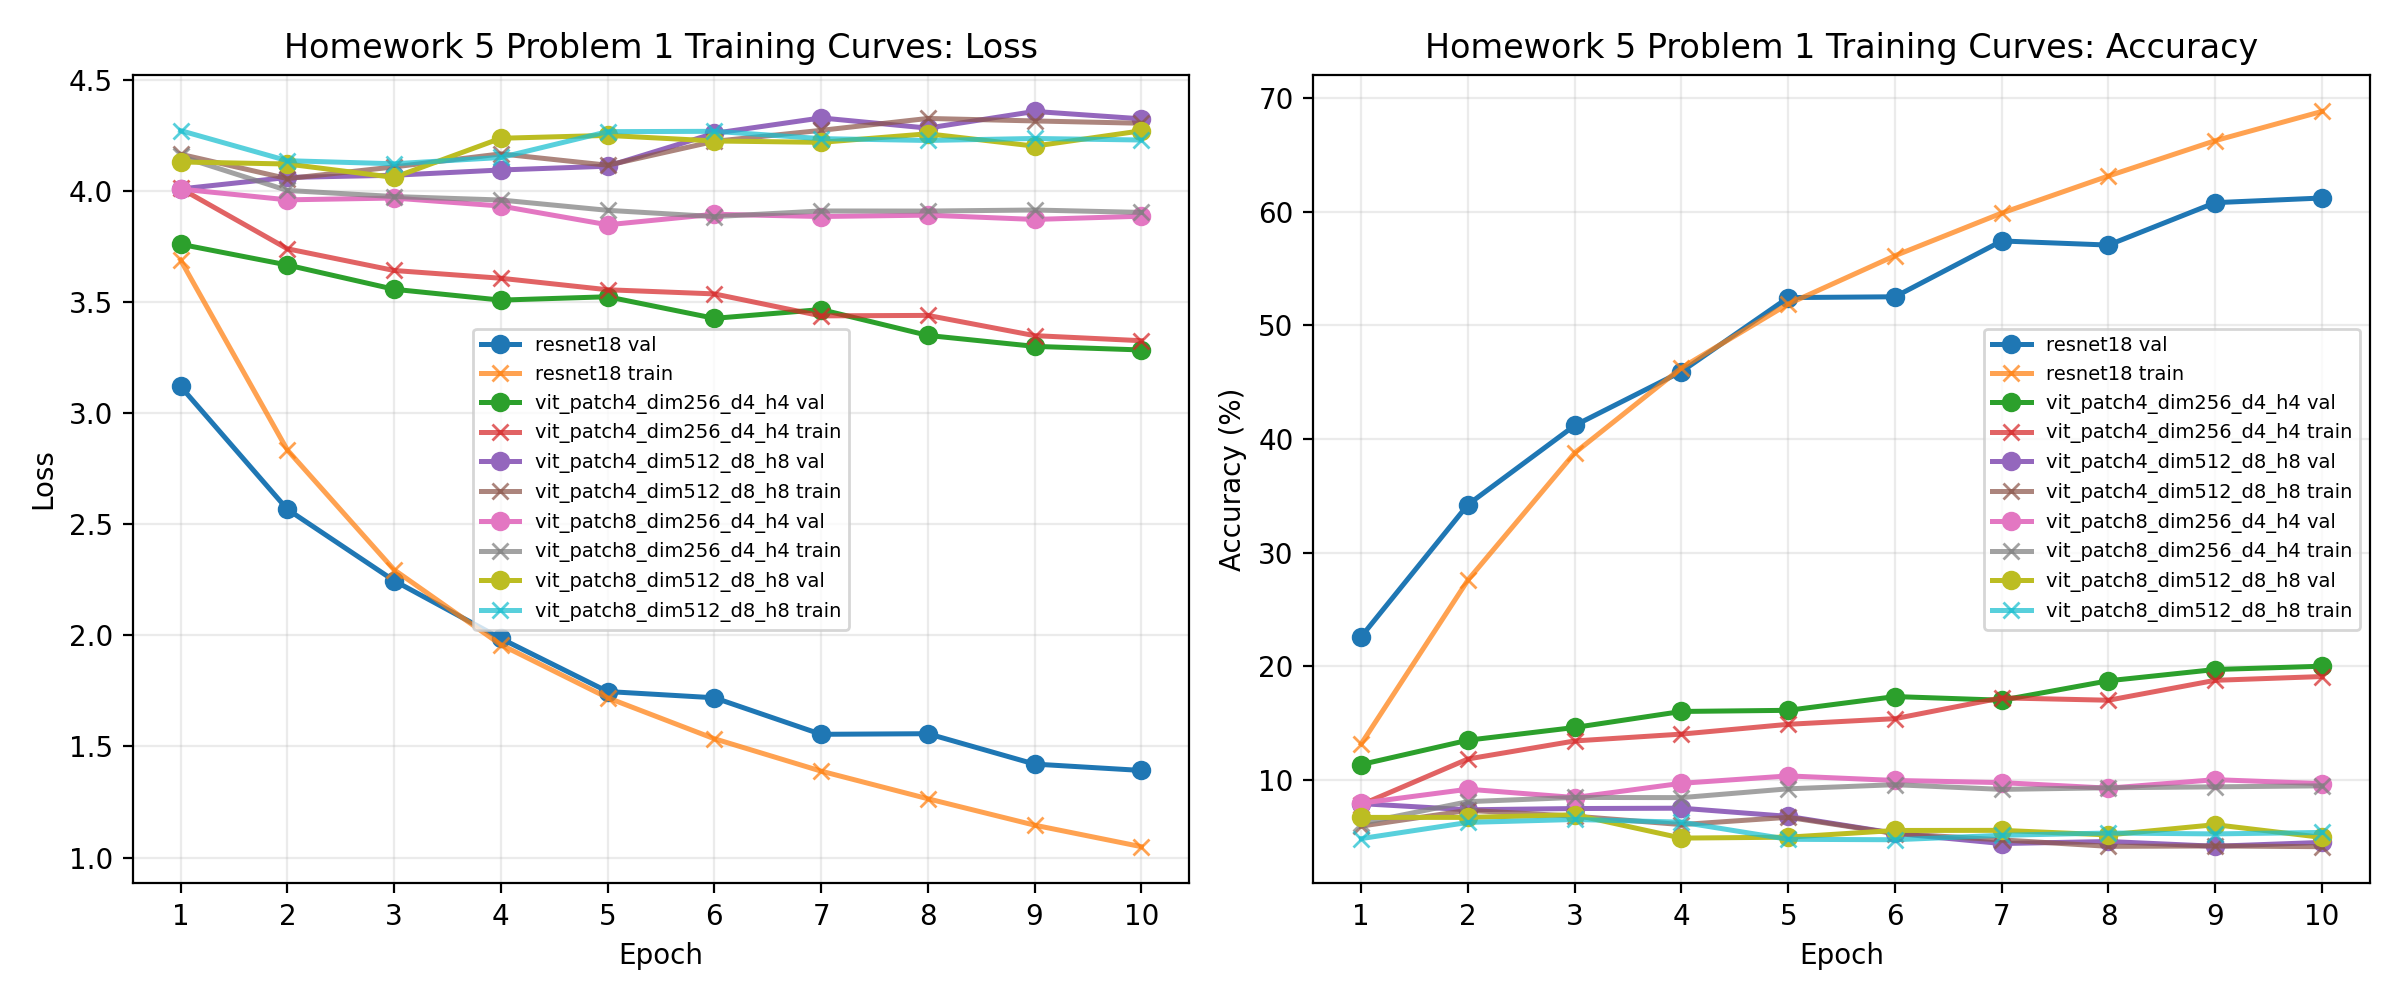

### Per-Model Accuracy Points

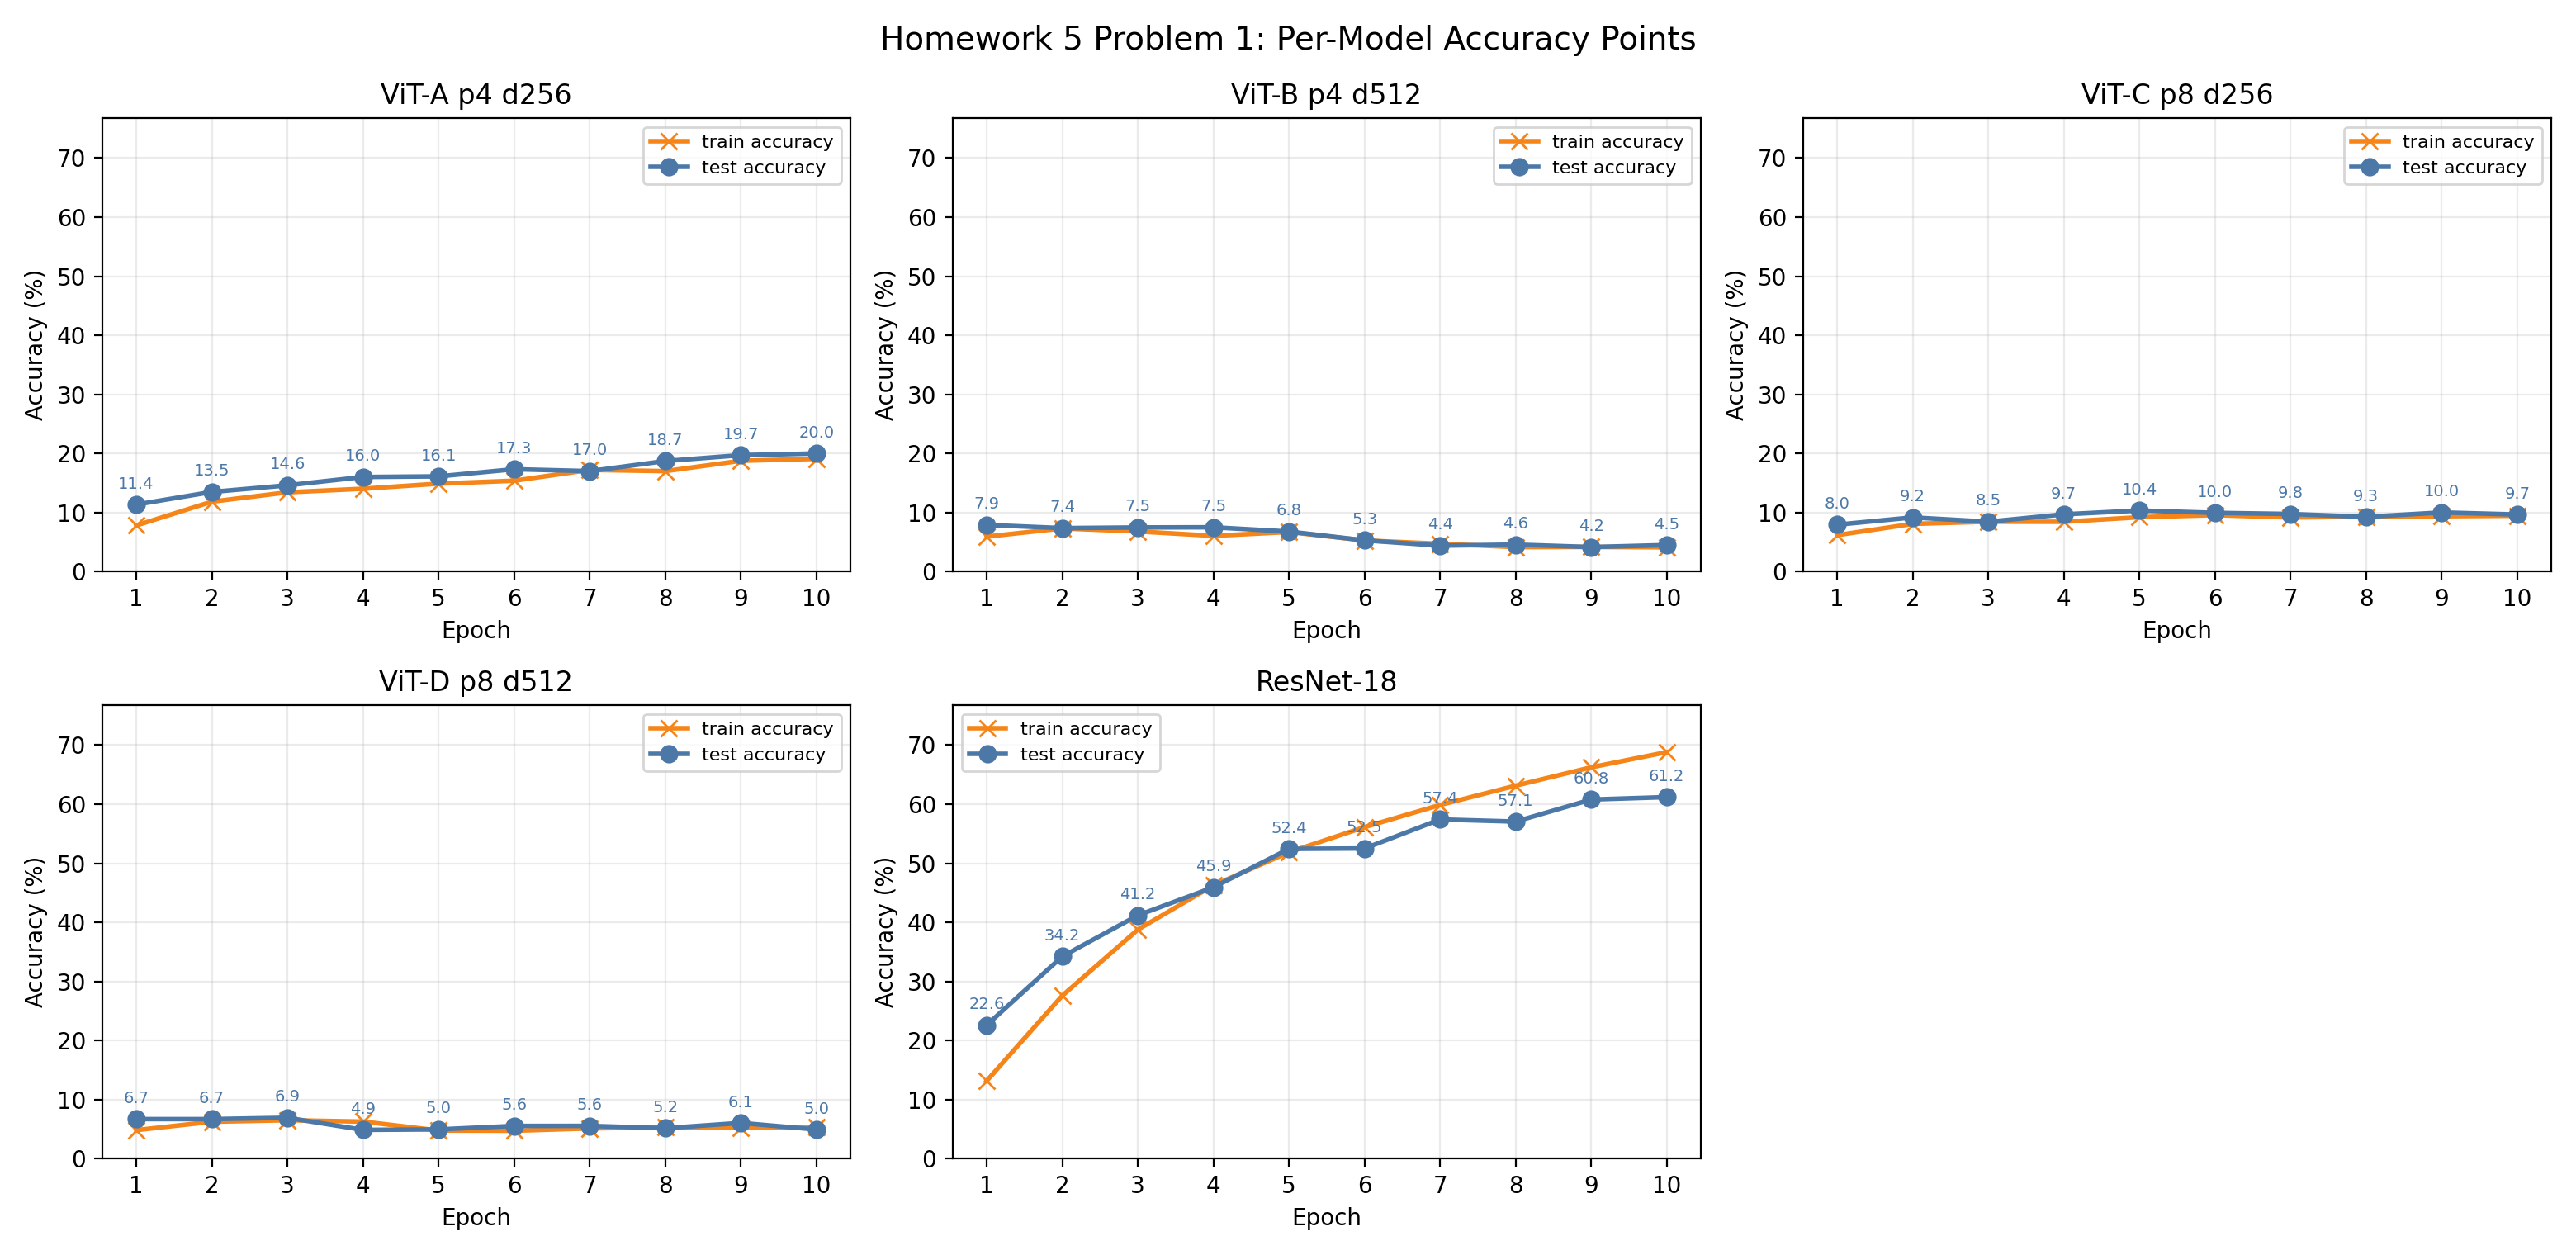

### Per-Epoch Metric Grid

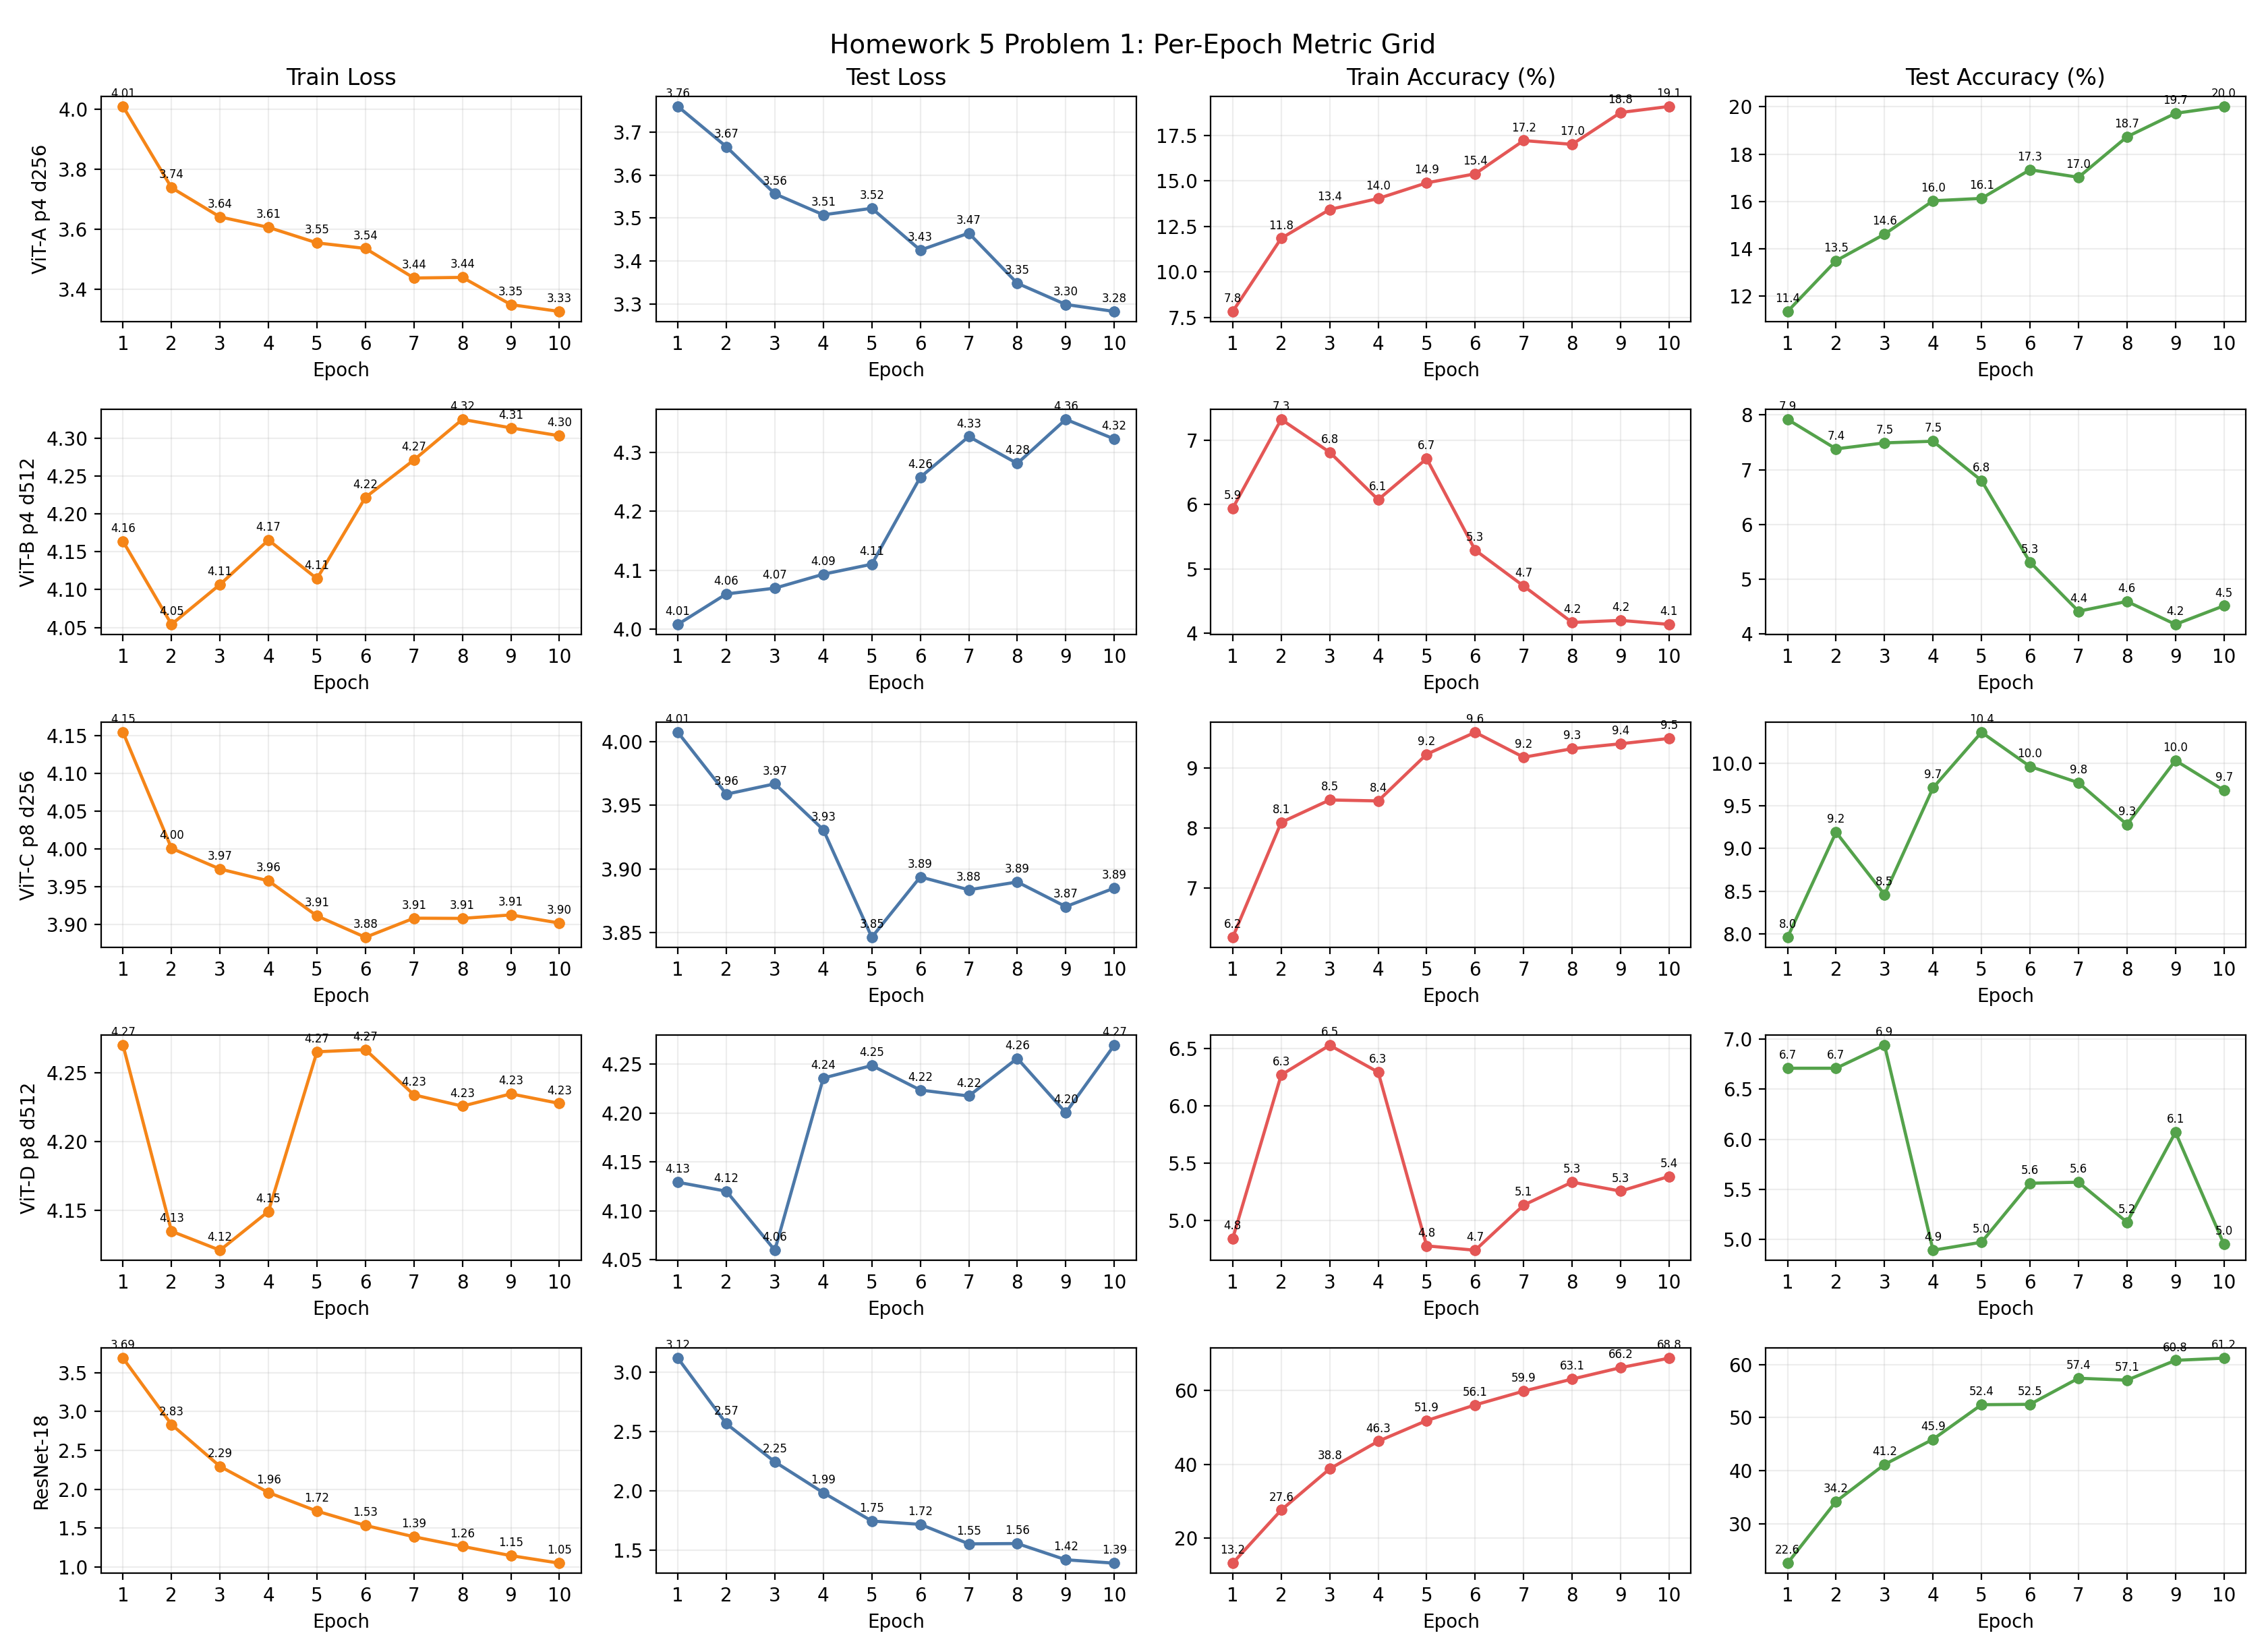

### Accuracy, Runtime, and Compute Tradeoffs

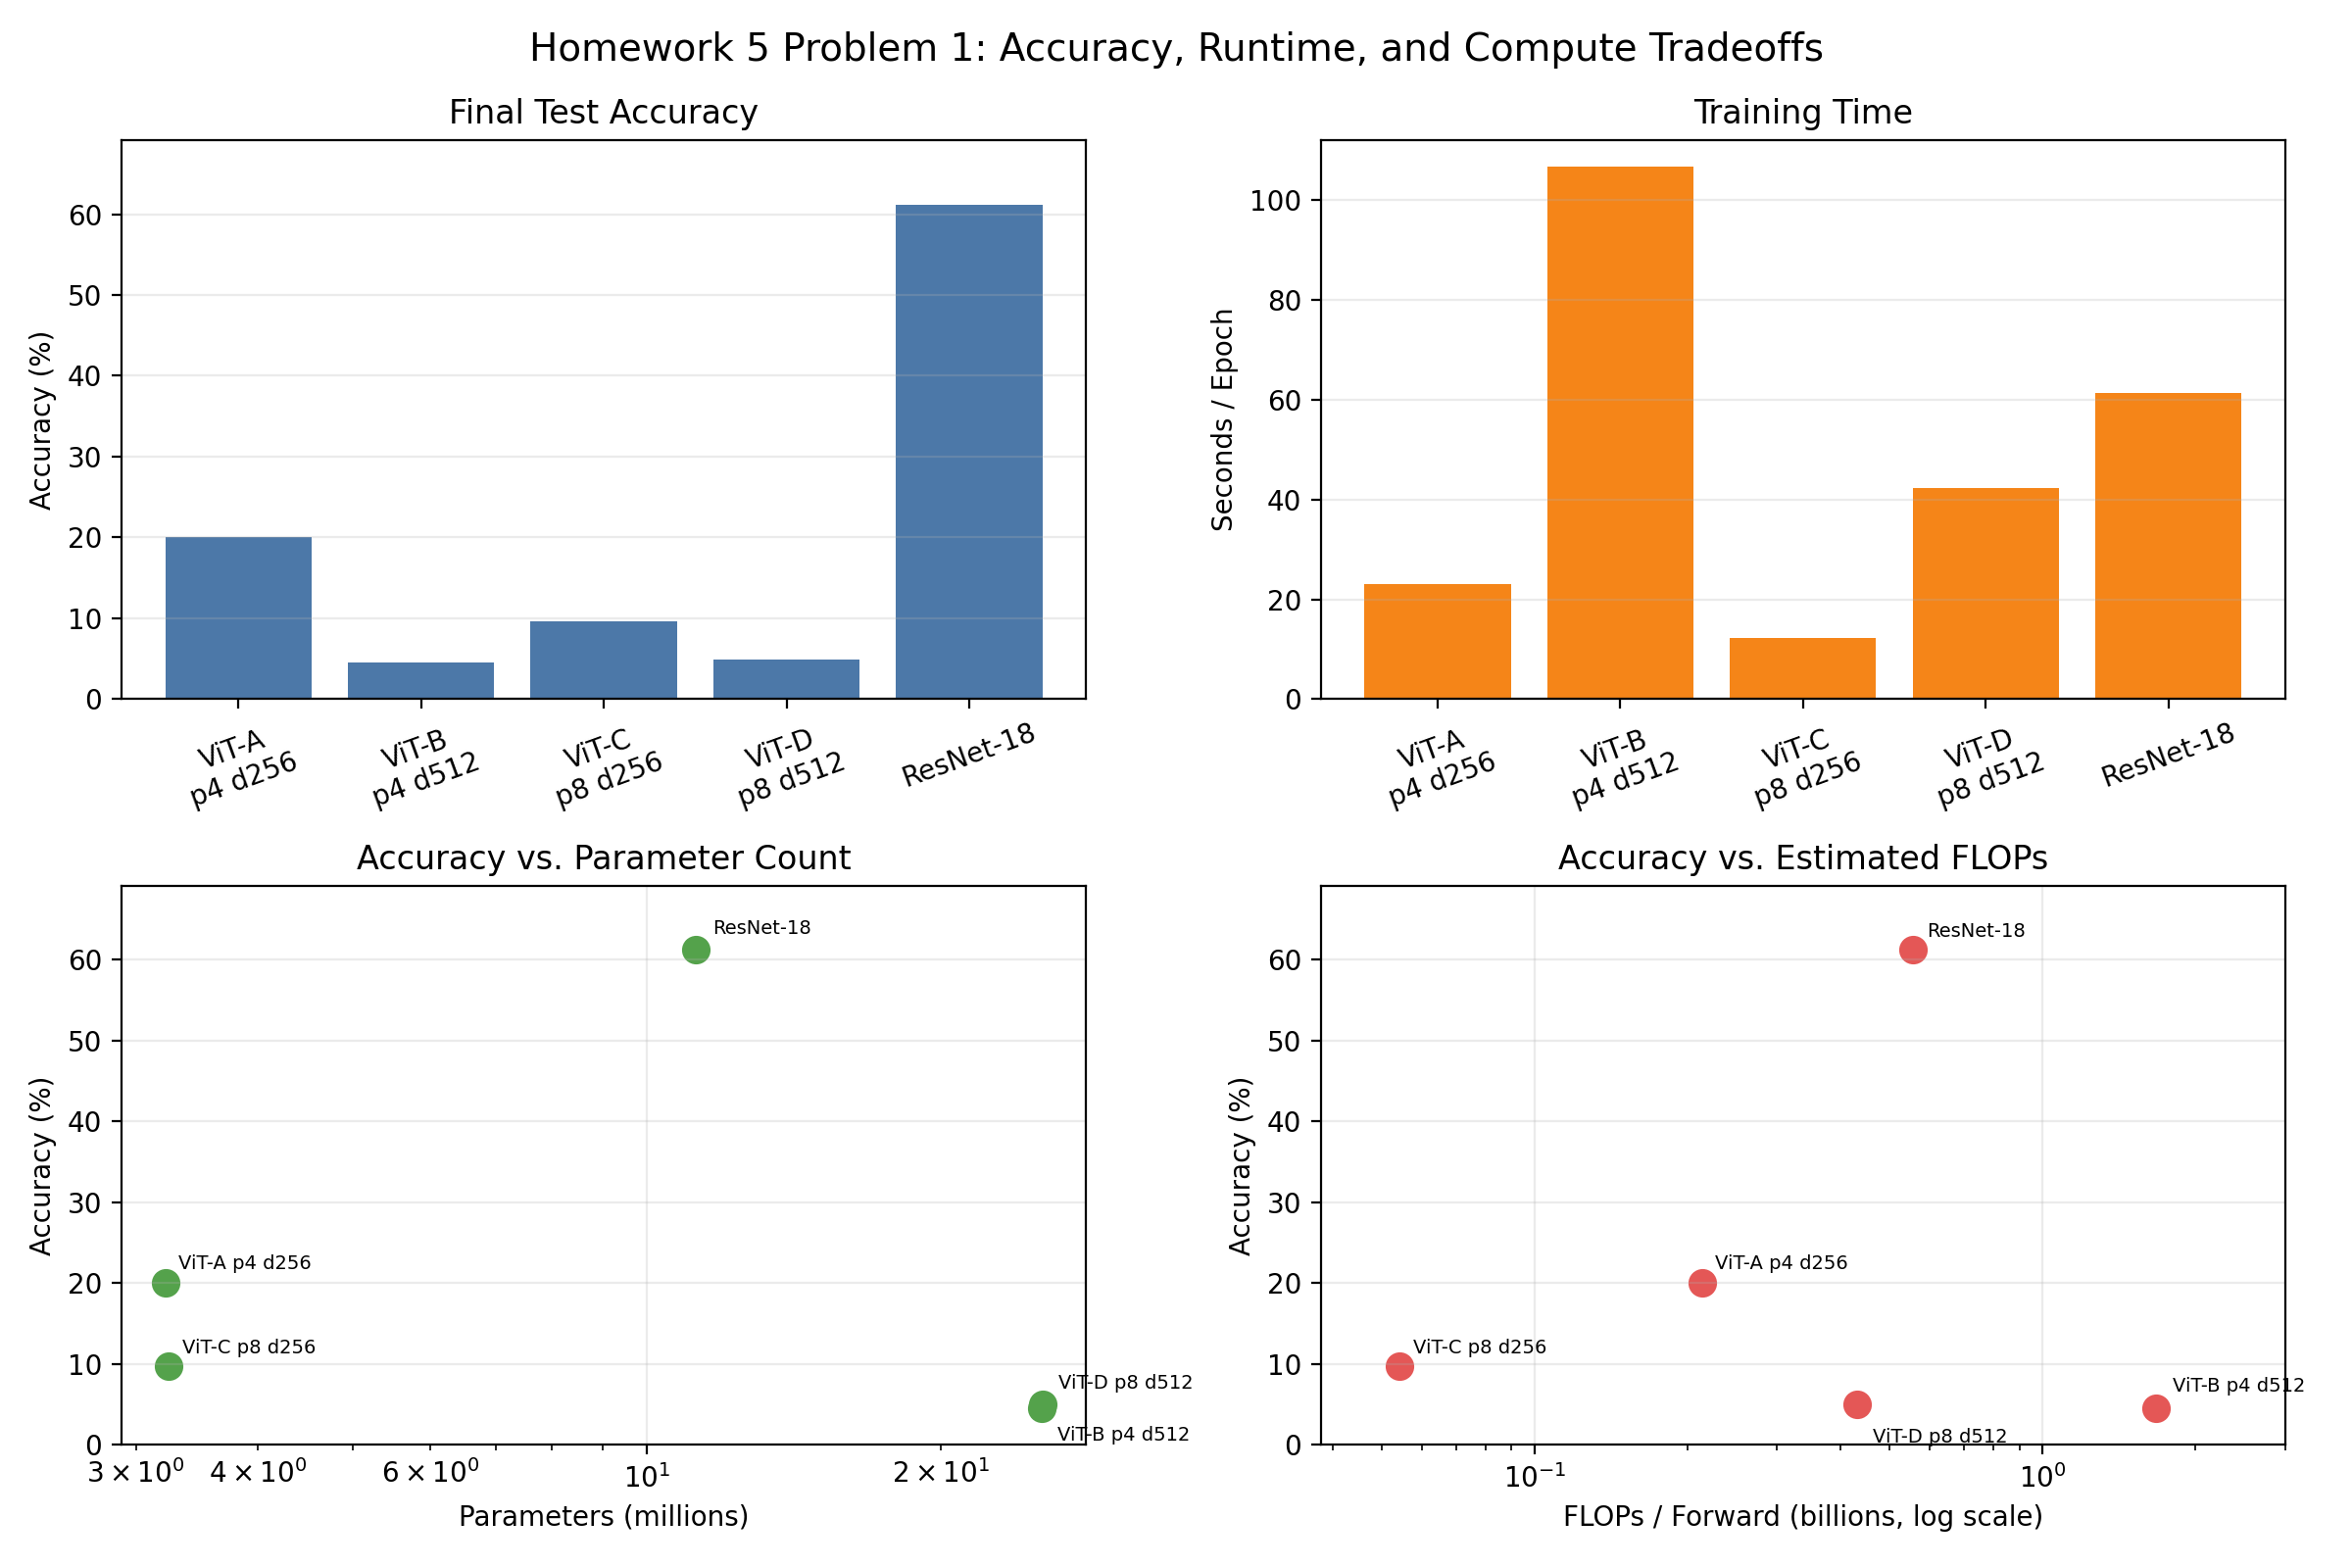

In [15]:
display(Markdown('### Loss and Accuracy Curves'))
display(Image(filename=str(plot_path)))
display(Markdown('### Per-Model Accuracy Points'))
display(Image(filename=str(detail_path)))
display(Markdown('### Per-Epoch Metric Grid'))
display(Image(filename=str(metric_grid_path)))
display(Markdown('### Accuracy, Runtime, and Compute Tradeoffs'))
display(Image(filename=str(tradeoff_path)))

## Interpretation

The best from-scratch ViT is `vit_patch4_dim256_d4_h4`, which reaches 20.01% test accuracy. It benefits from the smaller 4 by 4 patches because the model receives more spatial tokens and keeps more local image detail. `vit_patch8_dim256_d4_h4` is faster and has the lowest FLOP estimate, but its larger patches discard more fine-grained information and its accuracy drops to 9.68%.

The larger ViT settings do not improve the result under this short 10-epoch schedule. `vit_patch4_dim512_d8_h8` and `vit_patch8_dim512_d8_h8` have far more parameters, but their training curves stay close to high cross-entropy loss and low accuracy. That suggests the issue is optimization under the assignment schedule, not a lack of model capacity.

ResNet-18 is the strongest model in Problem 1 at 61.20% test accuracy. This is expected on CIFAR-100 because convolution gives a strong local-image inductive bias, while a ViT trained from scratch usually needs longer schedules, stronger regularization, or pretraining to compete.
